In [25]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture as gmm

Matplotlib is building the font cache; this may take a moment.


In [26]:
df = pd.read_csv(r'/Users/jmarc/ BU/Github_Repos/sports_betting/data/new_combined.csv')
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8007 entries, 0 to 8006
Data columns (total 208 columns):
 #    Column                                Dtype  
---   ------                                -----  
 0    td_defense_pct_red                    float64
 1    td_total_attempted_against_red        float64
 2    td_total_landed_against_red           float64
 3    td_defense_pct_blue                   float64
 4    td_total_attempted_against_blue       float64
 5    td_total_landed_against_blue          float64
 6    sig_str_defense_pct_red               float64
 7    sig_str_total_attempted_against_red   float64
 8    sig_str_total_landed_against_red      float64
 9    sig_str_defense_pct_blue              float64
 10   sig_str_total_attempted_against_blue  float64
 11   sig_str_total_landed_against_blue     float64
 12   td_accuracy_pct_red                   float64
 13   td_accuracy_pct_blue                  float64
 14   sig_str_accuracy_pct_red              float64
 15   si

In [9]:
pd.set_option('display.max_rows', None)
df.isna().sum()

td_defense_pct_red                       772
td_total_attempted_against_red           772
td_total_landed_against_red              772
td_defense_pct_blue                     1605
td_total_attempted_against_blue         1605
td_total_landed_against_blue            1605
sig_str_defense_pct_red                  772
sig_str_total_attempted_against_red      772
sig_str_total_landed_against_red         772
sig_str_defense_pct_blue                1605
sig_str_total_attempted_against_blue    1605
sig_str_total_landed_against_blue       1605
td_accuracy_pct_red                      772
td_accuracy_pct_blue                    1605
sig_str_accuracy_pct_red                 772
sig_str_accuracy_pct_blue               1605
kd_pm_red                                772
kd_total_red                             772
kd_pm_blue                              1605
kd_total_blue                           1605
sig_str_landed_pm_red                    772
sig_str_landed_total_red                 772
sig_str_la

In [32]:
df_model = df[df['winner']!=2]
df_model = df_model.dropna().reset_index(drop=True)

blue_feats = ['td_defense_pct_blue','td_accuracy_pct_blue', 'control_pm_blue',
 'sig_str_defense_pct_blue', 'sig_str_accuracy_pct_blue', 'sig_str_landed_pm_blue','sig_str_absorbed_pm_blue',
  'kd_pm_blue', 'total_fight_time_blue', 'age_blue', 'reach_blue', 'total_bonus_blue', 'elo_blue',
  'win_pct_blue', 'ko_losses_blue']

red_feats = ['td_defense_pct_red', 'td_accuracy_pct_red', 'control_pm_red',
 'sig_str_defense_pct_red', 'sig_str_accuracy_pct_red', 'sig_str_landed_pm_red', 'sig_str_absorbed_pm_red',
 'kd_pm_red',
 'total_fight_time_red', 'age_red', 'reach_red', 'total_bonus_red', 
 'elo_red', 'win_pct_red', 'ko_losses_red']
 # seperate by men/women, see womens_fight

def strip_suffix(cols, suffix):
    return [c.replace(suffix, "") for c in cols]

df_mens = df_model[df_model['womens_fight']==0]
df_mens_red  = df_mens[red_feats].rename(columns=lambda x: x.replace("_red", ""))
df_mens_blue = df_mens[blue_feats].rename(columns=lambda x: x.replace("_blue", ""))

df_womens = df_model[df_model['womens_fight']==1]
df_womens_red  = df_womens[red_feats].rename(columns=lambda x: x.replace("_red", ""))
df_womens_blue = df_womens[blue_feats].rename(columns=lambda x: x.replace("_blue", ""))

df_men_all = pd.concat([df_mens_red, df_mens_blue], axis=0, join="inner") # columns automatically aligned by name 
df_women_all = pd.concat([df_womens_red, df_womens_blue], axis=0, join="inner")


In [35]:
corr = df_men_all.corr()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle, no duplicates
        .stack()
        .reset_index()
)

corr_pairs.columns = ['variable_1', 'variable_2', 'correlation']

# filter by threshold
strong_corr = corr_pairs[abs(corr_pairs['correlation']) > 0.5]

strong_corr

,variable_1,variable_2,correlation
39,sig_str_defense_pct,sig_str_accuracy_pct,-0.523679
60,sig_str_landed_pm,sig_str_absorbed_pm,0.561858
86,total_fight_time,total_bonus,0.704907
102,elo,win_pct,0.602215


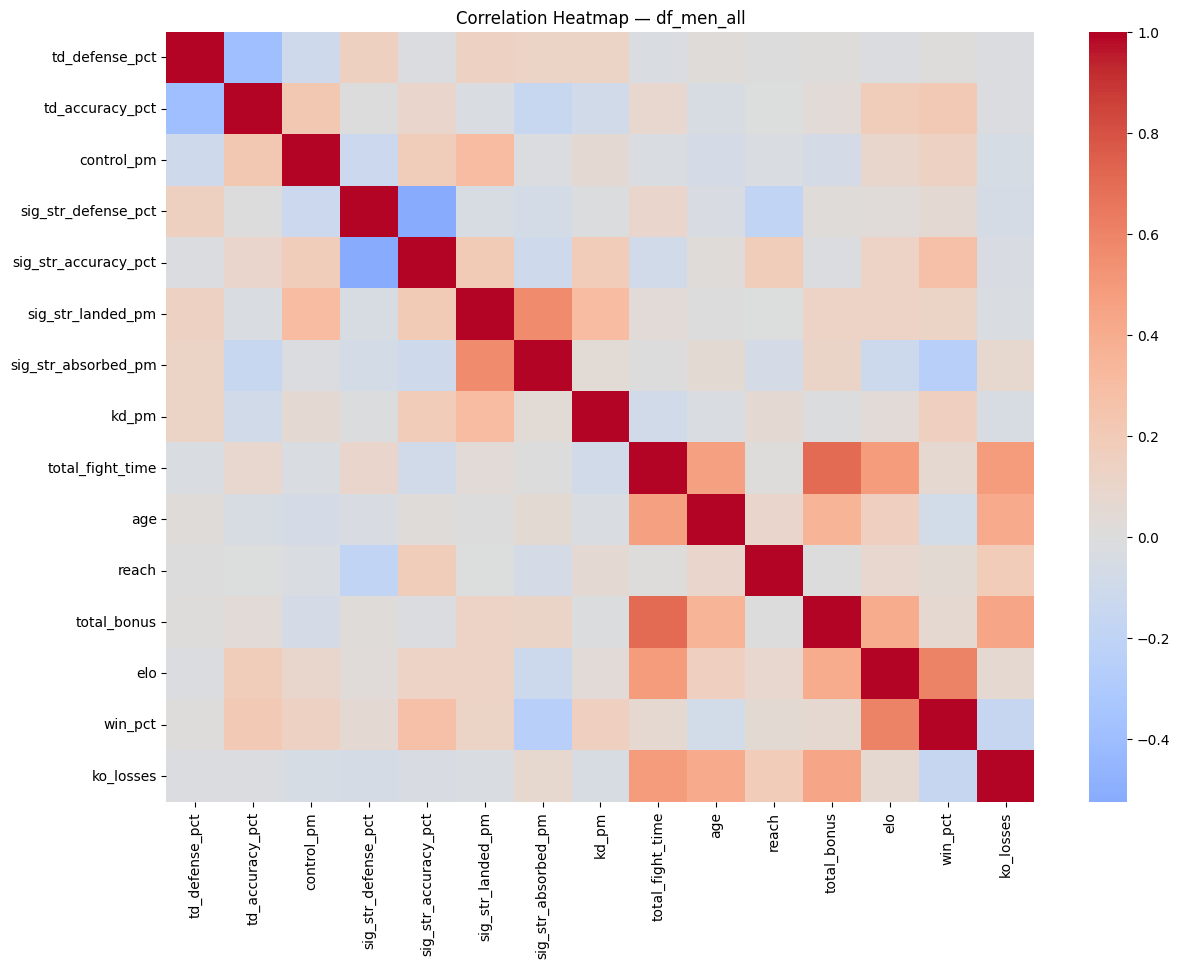

In [36]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Heatmap — df_men_all")
plt.show()

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


In [54]:
def fit_gmm(X, n_components=2, covariance_type="full", random_state=0):
    """
    Standardizes X, fits a GMM, and computes silhouette score.
    Returns: model, labels, X_proc, silhouette
    """
    scaler = StandardScaler()
    X_proc = scaler.fit_transform(X)

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state
    )
    gmm.fit(X_proc)
    labels = gmm.predict(X_proc)

    # compute silhouette
    sil = silhouette_score(X_proc, labels)

    return gmm, labels, X_proc, sil

def compute_aic_bic(X, component_range=range(1, 15), covariance_type="full", random_state=0):
    """
    Fits GMM for each k in component_range and computes AIC & BIC.
    Returns: components, aics, bics
    """
    scaler = StandardScaler()
    X_proc = scaler.fit_transform(X)

    aics = []
    bics = []

    for k in component_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=random_state
        )
        gmm.fit(X_proc)
        aics.append(gmm.aic(X_proc))
        bics.append(gmm.bic(X_proc))

    plt.figure(figsize=(10, 6))
    plt.plot(component_range, aics, label="AIC")
    plt.plot(component_range, bics, label="BIC")
    plt.xlabel("Number of Components")
    plt.ylabel("Information Criterion")
    plt.title("GMM Model Selection via AIC & BIC")
    plt.legend()
    plt.grid(True)
    plt.show()
    return list(component_range), aics, bics


def plot_pca_clusters(X_proc, labels, title="PCA Cluster Plot"):
    """
    Creates a PCA 2D scatter plot of processed data colored by cluster labels,
    with axis labels showing explained variance.
    """
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_proc)
    
    # Extract explained variance ratios
    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=30, alpha=0.8)

    plt.title(title)
    plt.xlabel(f"PCA 1 ({var1:.2f}% variance)")
    plt.ylabel(f"PCA 2 ({var2:.2f}% variance)")
    plt.grid(True)

    plt.show()

Silhouette: 0.0741972506110499


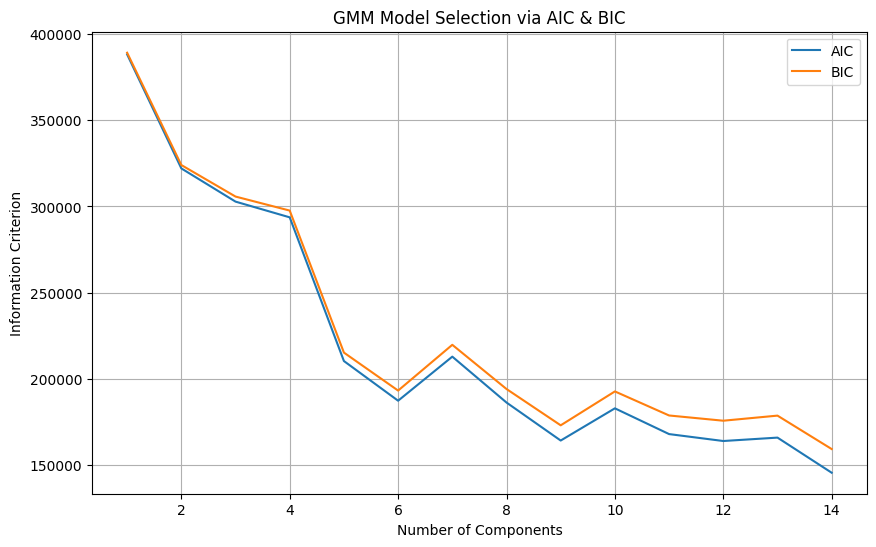

In [56]:
gmm, labels, X_proc, sil = fit_gmm(df_men_all, n_components=4)
print("Silhouette:", sil)

components, aics, bics = compute_aic_bic(df_men_all)


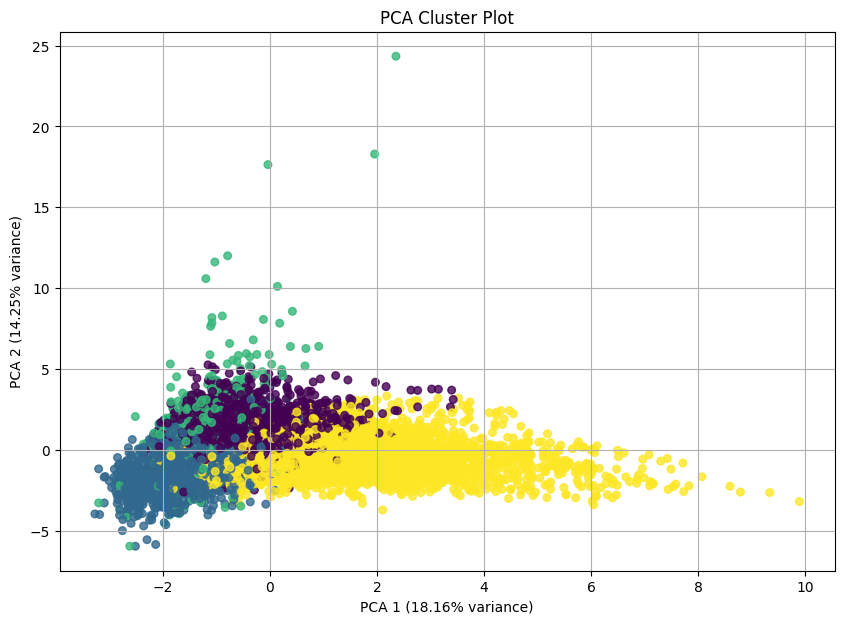

In [57]:
plot_pca_clusters(X_proc, labels)


Silhouette: 0.04572825204172518


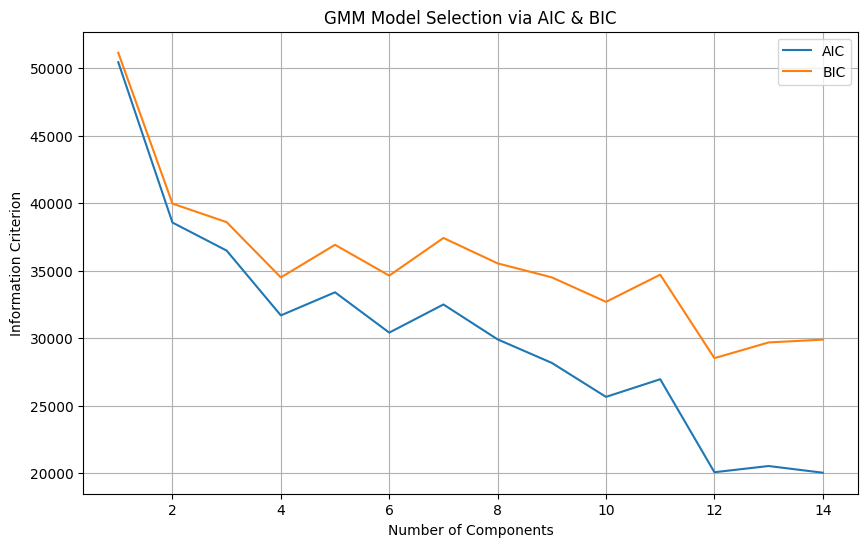

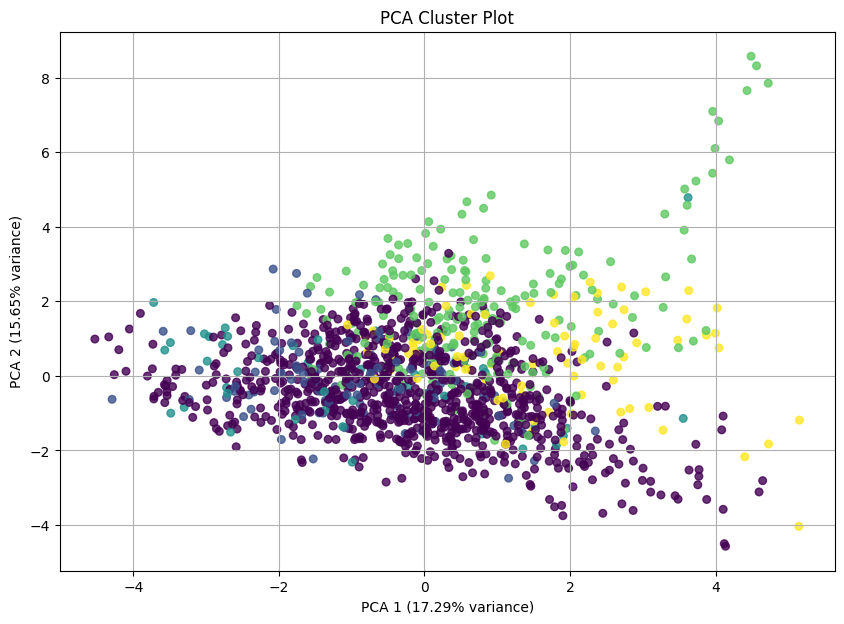

In [64]:
gmm, labels, X_proc, sil = fit_gmm(df_women_all, n_components=5)
print("Silhouette:", sil)

components, aics, bics = compute_aic_bic(df_women_all)
plot_pca_clusters(X_proc, labels)
